# Some setup

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from datetime import timedelta
import ast
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import LSTM, Dense
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam

%matplotlib inline  
from pylab import rcParams
rcParams['figure.figsize'] = 15, 8

# Store 44, GROCERY I Sales Forecasting with LSTM & Prophet

### 3.1  Data Loading and Feature Engineering

In [27]:
# ── 1. Filter train.csv for Store 44 / GROCERY I ──────────────────
print("Loading train.csv …")
train_df = pd.read_csv('dataset/train.csv', parse_dates=['date'])

mask = (train_df['store_nbr'] == 44) & (train_df['family'] == 'GROCERY I')
df = train_df[mask].copy()

# Aggregate daily sales + onpromotion
daily = (df.groupby('date')
           .agg(sales=('sales', 'sum'),
                onpromotion=('onpromotion', 'sum'))
           .reset_index()
           .sort_values('date')
           .reset_index(drop=True))

# ── 2. Merge oil prices ─────────────────────────────────────────────
print("Loading oil.csv …")
oil = pd.read_csv('dataset/oil.csv', parse_dates=['date'])
oil.columns = ['date', 'oil_price']
oil['oil_price'] = oil['oil_price'].ffill().bfill()   # fill weekends / gaps

daily = daily.merge(oil, on='date', how='left')
daily['oil_price'] = daily['oil_price'].ffill().bfill()

# ── 3. Merge holidays ───────────────────────────────────────────────
print("Loading holidays_events.csv …")
hol = pd.read_csv('dataset/holidays_events.csv', parse_dates=['date'])

# Mark any date that appears in the file as a holiday
holiday_dates = hol[hol['type'].isin(['Holiday', 'Event', 'Additional',
                                      'Bridge', 'Transfer', 'Work Day'])]['date'].unique()
daily['is_holiday'] = daily['date'].isin(holiday_dates).astype(int)

print(f"\nDataframe shape: {daily.shape}")
print(f"Date range: {daily['date'].min().date()} → {daily['date'].max().date()}")
daily.head(10)


Loading train.csv …
Loading oil.csv …
Loading holidays_events.csv …

Dataframe shape: (1684, 5)
Date range: 2013-01-01 → 2017-08-15


,date,sales,onpromotion,oil_price,is_holiday
0,2013-01-01,0.0,0,93.14,1
1,2013-01-02,10686.0,0,93.14,0
2,2013-01-03,7342.0,0,92.97,0
3,2013-01-04,7250.0,0,93.12,0
4,2013-01-05,10699.0,0,93.12,1
5,2013-01-06,12373.0,0,93.12,0
6,2013-01-07,7059.0,0,93.20,0
7,2013-01-08,19849.0,0,93.21,0
8,2013-01-09,7546.0,0,93.08,0
9,2013-01-10,5101.0,0,93.81,0


### 3.2  Inspect the Feature DataFrame

date           datetime64[us]
sales                 float64
onpromotion             int64
oil_price             float64
is_holiday              int64
dtype: object

Null values:
date           0
sales          0
onpromotion    0
oil_price      0
is_holiday     0
dtype: int64


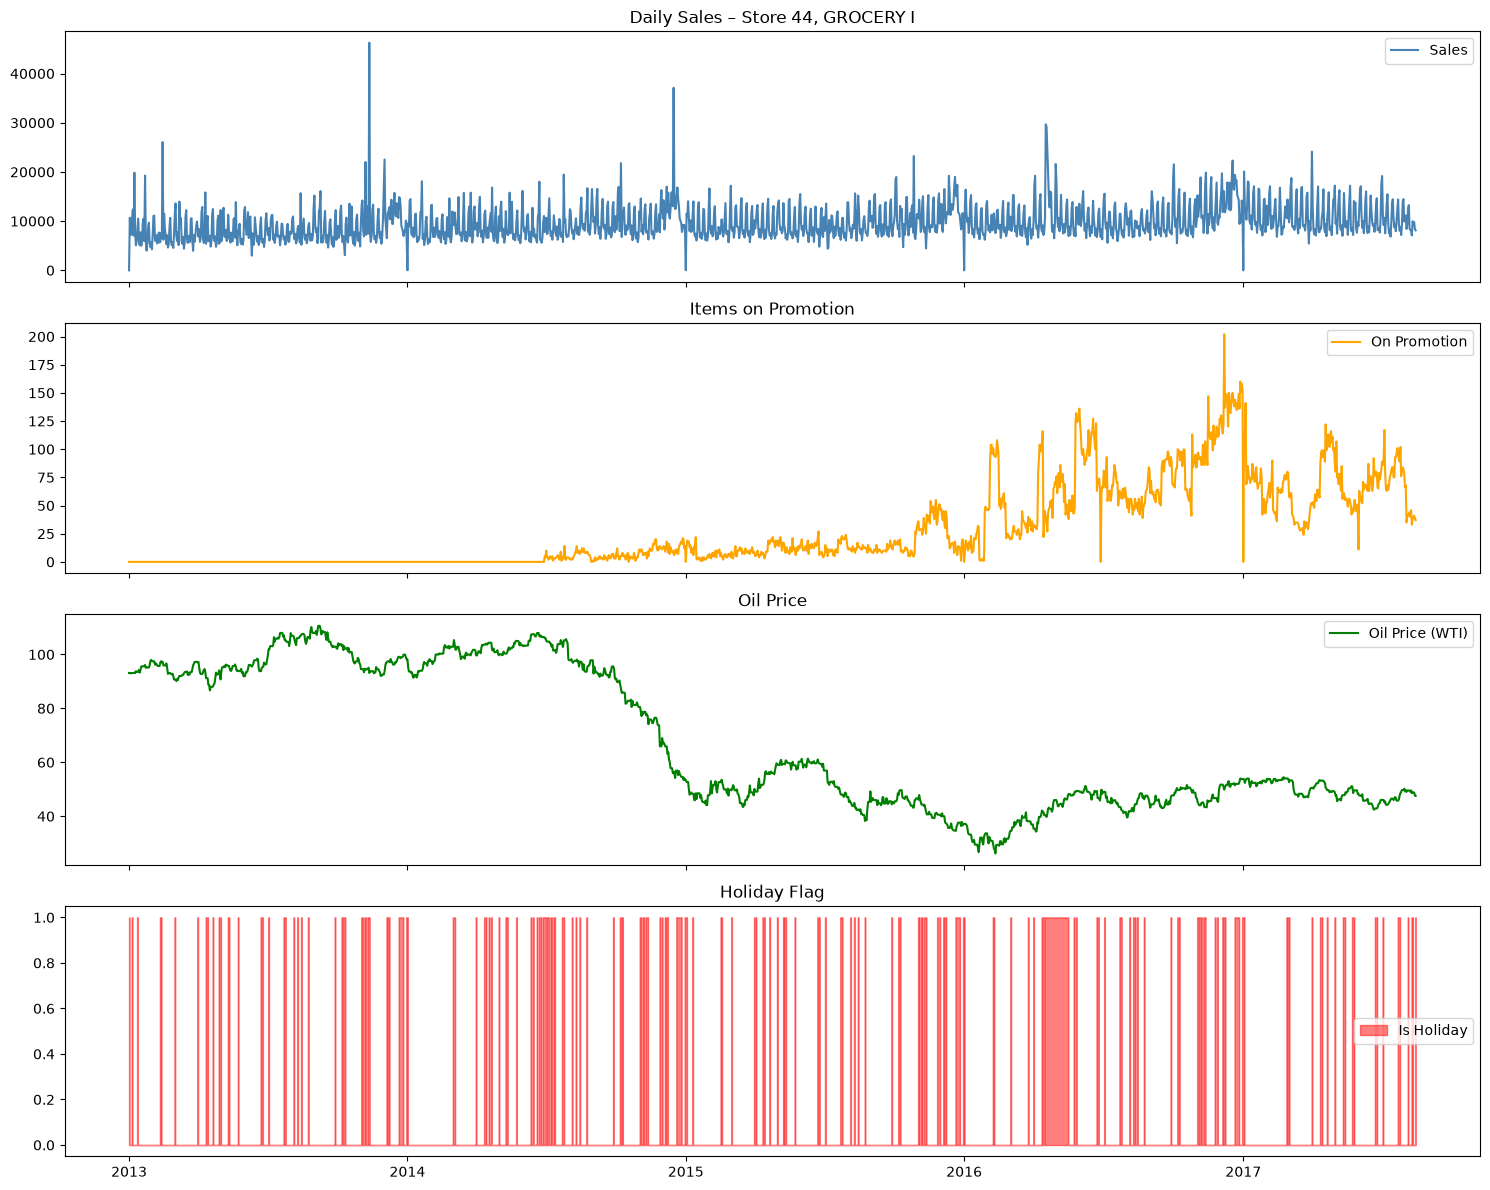

In [28]:
print(daily.dtypes)
print("\nNull values:")
print(daily.isnull().sum())

fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
axes[0].plot(daily['date'], daily['sales'], label='Sales', color='steelblue')
axes[0].set_title('Daily Sales – Store 44, GROCERY I')
axes[0].legend()

axes[1].plot(daily['date'], daily['onpromotion'], label='On Promotion', color='orange')
axes[1].set_title('Items on Promotion')
axes[1].legend()

axes[2].plot(daily['date'], daily['oil_price'], label='Oil Price (WTI)', color='green')
axes[2].set_title('Oil Price')
axes[2].legend()

axes[3].fill_between(daily['date'], daily['is_holiday'],
                     label='Is Holiday', color='red', alpha=0.5, step='mid')
axes[3].set_title('Holiday Flag')
axes[3].legend()

plt.tight_layout()
plt.show()


### 3.3  Prophet Model (with Regressors)

Prophet  →  train: 1347 days  |  val: 337 days


16:37:29 - cmdstanpy - INFO - Chain [1] start processing
16:37:29 - cmdstanpy - INFO - Chain [1] done processing


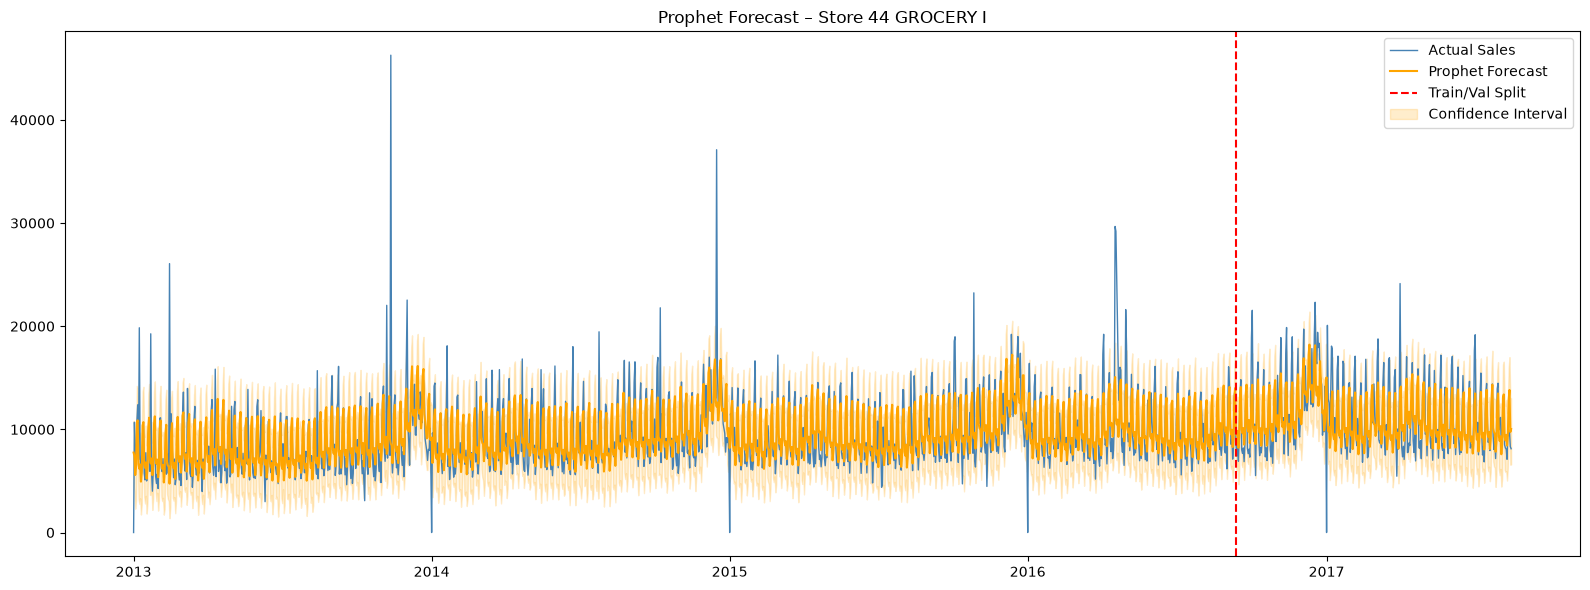

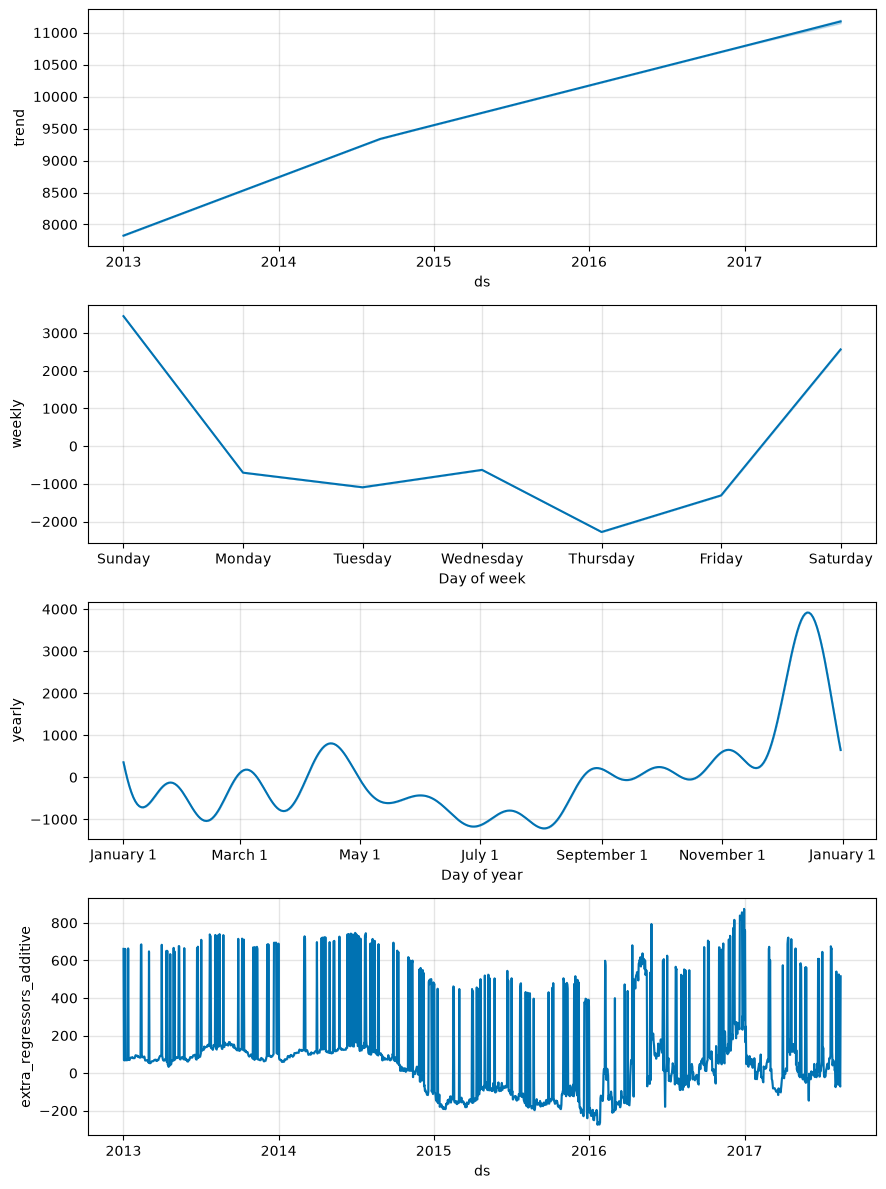


Prophet Validation MAE: 1631.05


In [29]:
# ── Prophet ────────────────────────────────────────────────────────
# 80 / 20 chronological split
n_total   = len(daily)
n_train   = int(n_total * 0.80)

train_prophet = daily.iloc[:n_train].copy()
val_prophet   = daily.iloc[n_train:].copy()

print(f"Prophet  →  train: {len(train_prophet)} days  |  val: {len(val_prophet)} days")

prophet_train = train_prophet[['date', 'sales']].rename(columns={'date': 'ds', 'sales': 'y'})
prophet_val   = val_prophet[['date', 'sales']].rename(columns={'date': 'ds', 'sales': 'y'})

# Add regressors to training df
prophet_train['onpromotion'] = train_prophet['onpromotion'].values
prophet_train['oil_price']   = train_prophet['oil_price'].values
prophet_train['is_holiday']  = train_prophet['is_holiday'].values

m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
m.add_regressor('onpromotion')
m.add_regressor('oil_price')
m.add_regressor('is_holiday')
m.fit(prophet_train)

# Build future dataframe directly from our daily dates to perfectly align the calendar
future = daily[['date', 'onpromotion', 'oil_price', 'is_holiday']].copy()
future = future.rename(columns={'date': 'ds'})

forecast = m.predict(future)
# ── Plot forecast vs actuals ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(daily['date'], daily['sales'], label='Actual Sales', color='steelblue', linewidth=1)
ax.plot(forecast['ds'], forecast['yhat'], label='Prophet Forecast', color='orange', linewidth=1.5)
ax.axvline(daily['date'].iloc[n_train], color='red', linestyle='--', label='Train/Val Split')
ax.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                alpha=0.2, color='orange', label='Confidence Interval')
ax.set_title('Prophet Forecast – Store 44 GROCERY I')
ax.legend()
plt.tight_layout()
plt.show()

# ── Components ─────────────────────────────────────────────────────
fig2 = m.plot_components(forecast)
plt.show()

# ── Validation MAE ─────────────────────────────────────────────────
val_results  = prophet_val.merge(forecast[['ds', 'yhat']], on='ds', how='inner')
mae_prophet  = np.mean(np.abs(val_results['yhat'] - val_results['y']))
print(f"\nProphet Validation MAE: {mae_prophet:.2f}")


### 3.4  LSTM Model with Multivariate Features

In [30]:
# ── LSTM Feature Matrix ────────────────────────────────────────────
FEATURE_COLS = ['sales', 'onpromotion', 'oil_price', 'is_holiday']
LOOK_BACK    = 30   # use 30 days of history to predict the next day

data_arr = daily[FEATURE_COLS].values.astype('float32')

# Scale only numeric features (sales, onpromotion, oil_price); is_holiday stays 0/1
scaler       = MinMaxScaler(feature_range=(0, 1))
scaled_arr   = scaler.fit_transform(data_arr)   # fits on ALL data (ok – no leakage via look_back window)

# ── 80 / 20 chronological split ────────────────────────────────────
n_total   = len(scaled_arr)
n_train   = int(n_total * 0.80)

print(f"Total samples : {n_total}")
print(f"Train samples : {n_train}")
print(f"Val   samples : {n_total - n_train}")

def create_sequences(data, look_back):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i : i + look_back, :])       # all features
        y.append(data[i + look_back, 0])            # only sales
    return np.array(X), np.array(y)

# Create sequences from the entire scaled dataset
X_all, y_all = create_sequences(scaled_arr, LOOK_BACK)

# Split at 80 %
n_seq_train  = int(len(X_all) * 0.80)
X_train, X_val = X_all[:n_seq_train],  X_all[n_seq_train:]
y_train, y_val = y_all[:n_seq_train],  y_all[n_seq_train:]

print(f"\nX_train shape : {X_train.shape}  →  [{X_train.shape[0]} sequences, {X_train.shape[1]} timesteps, {X_train.shape[2]} features]")
print(f"X_val   shape : {X_val.shape}")


Total samples : 1684
Train samples : 1347
Val   samples : 337

X_train shape : (1323, 30, 4)  →  [1323 sequences, 30 timesteps, 4 features]
X_val   shape : (331, 30, 4)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 30, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,113 (117.63 KB)

 Trainable params: 30,113 (117.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - loss: 0.0123 - val_loss: 0.0076
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0099 - val_loss: 0.0072
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0142 - val_loss: 0.0062
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0104 - val_loss: 0.0067
Epoch 5/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0076 - val_loss: 0.0067
Epoch 6/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0059 - val_loss: 0.0069
Epoch 7/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0056 - val_loss: 0.0064
Epoch 8/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0057 - val_loss: 0.0063
Epoch 9/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0057 - val_loss: 0.0064
Epoch 10/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0058 - val_loss: 0.0065
Epoch 11/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0058 - val_loss: 0.0064
Epoch 12/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step

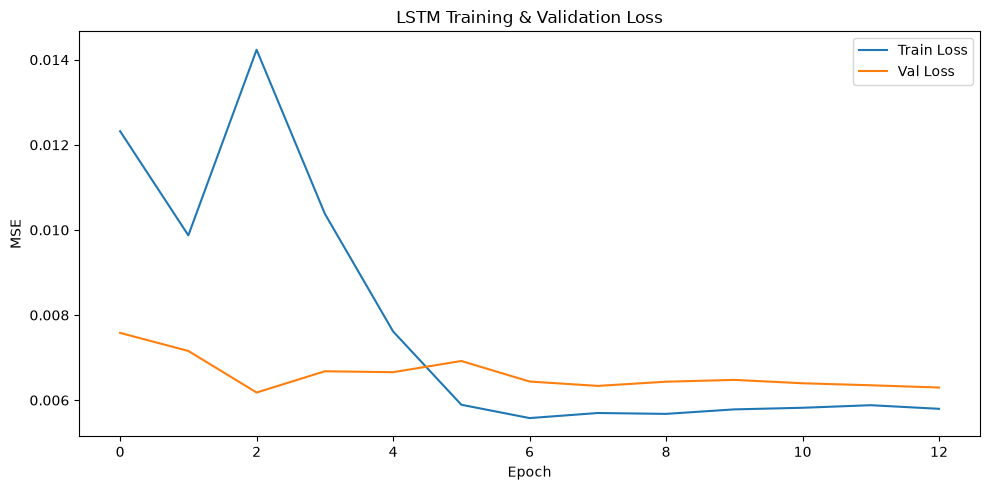

In [31]:
# ── Build LSTM Model ───────────────────────────────────────────────
n_features = X_train.shape[2]

lstm_model = Sequential([
    LSTM(64, input_shape=(LOOK_BACK, n_features), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(loss='mse', optimizer=Adam(learning_rate=0.001))
lstm_model.summary()

# ── Train ──────────────────────────────────────────────────────────
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = lstm_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1,
    shuffle=False          # time-series – do NOT shuffle
)

# ── Plot training loss ─────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.show()


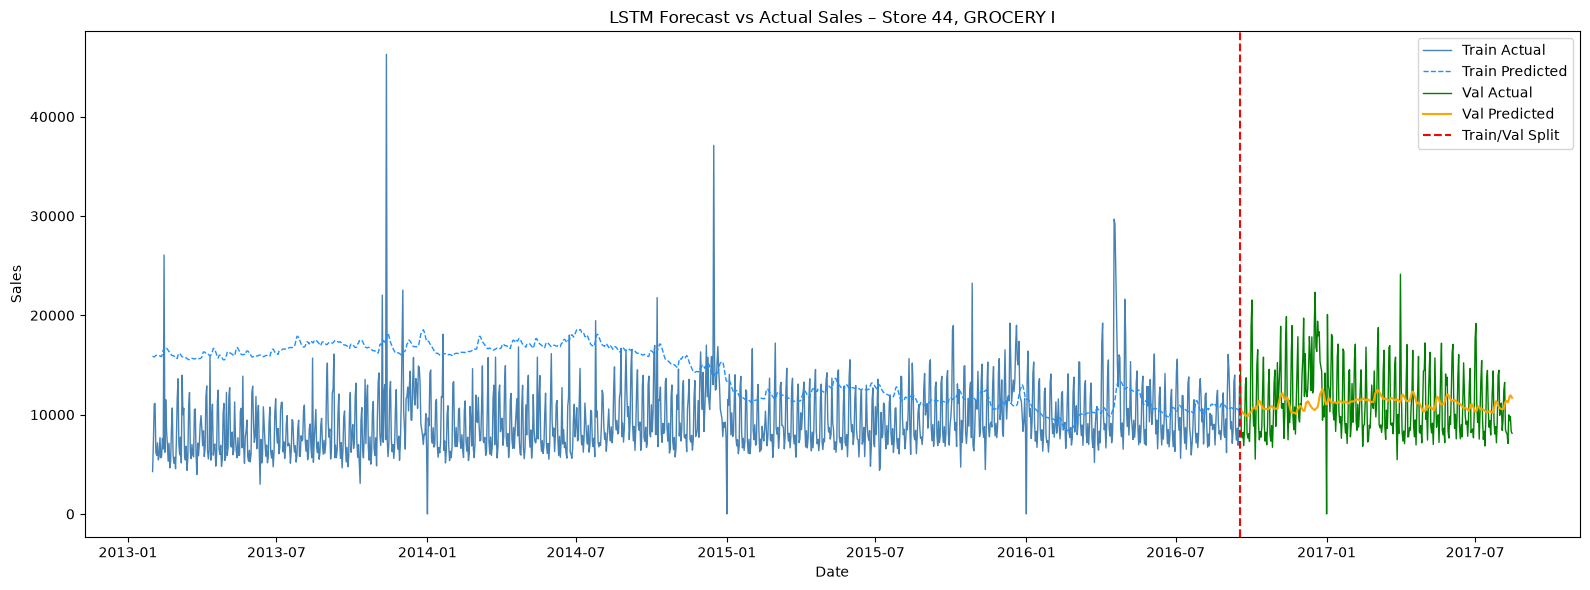

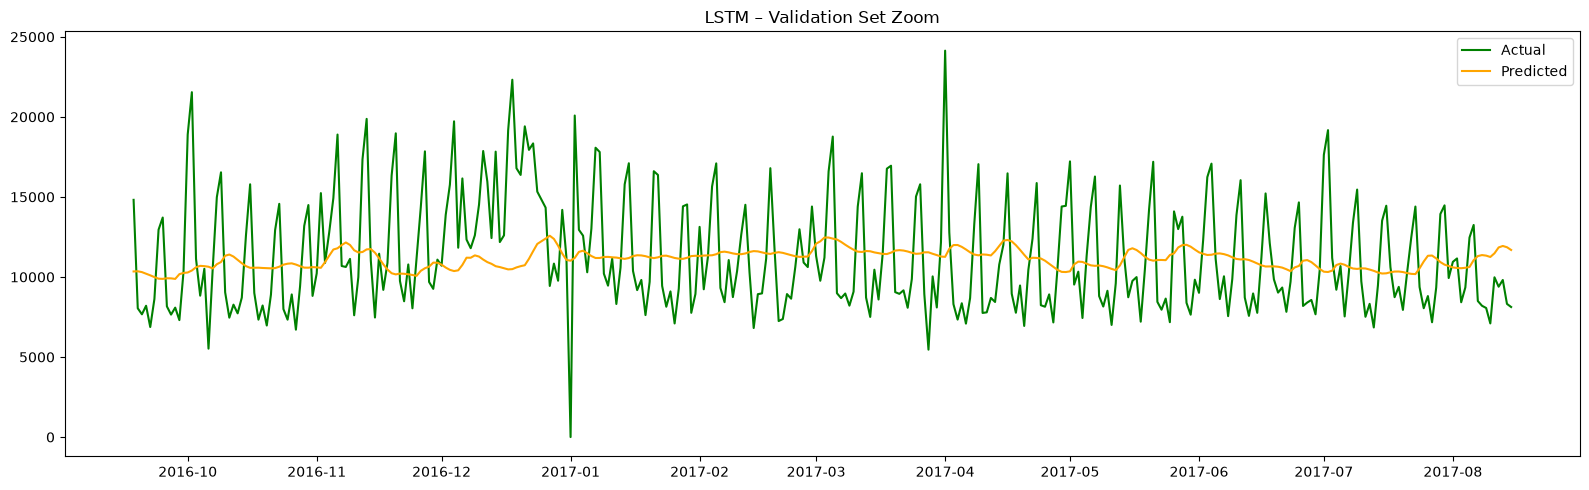

LSTM Validation MAE  : 2943.50
LSTM Validation RMSE : 3637.44


In [32]:
# ── Inverse-transform predictions to original scale ───────────────
def inverse_sales(scaled_sales, scaler, n_features):
    """Pad with zeros to match scaler width, then inverse transform."""
    placeholder = np.zeros((len(scaled_sales), n_features))
    placeholder[:, 0] = scaled_sales.flatten()
    return scaler.inverse_transform(placeholder)[:, 0]

y_train_pred = lstm_model.predict(X_train, verbose=0)
y_val_pred   = lstm_model.predict(X_val,   verbose=0)

y_train_inv   = inverse_sales(y_train,      scaler, n_features)
y_val_inv     = inverse_sales(y_val,        scaler, n_features)
y_train_p_inv = inverse_sales(y_train_pred, scaler, n_features)
y_val_p_inv   = inverse_sales(y_val_pred,   scaler, n_features)

# ── Reconstruct dates for plotting ─────────────────────────────────
dates_all    = daily['date'].values[LOOK_BACK:]
dates_train  = dates_all[:n_seq_train]
dates_val    = dates_all[n_seq_train:]

# ── Plot actual vs predicted (full timeline) ───────────────────────
plt.figure(figsize=(16, 6))
plt.plot(dates_train, y_train_inv,   label='Train Actual',    color='steelblue',  linewidth=1)
plt.plot(dates_train, y_train_p_inv, label='Train Predicted', color='dodgerblue', linewidth=1, linestyle='--')
plt.plot(dates_val,   y_val_inv,     label='Val Actual',      color='green',      linewidth=1)
plt.plot(dates_val,   y_val_p_inv,   label='Val Predicted',   color='orange',     linewidth=1.5)
plt.axvline(dates_val[0], color='red', linestyle='--', label='Train/Val Split')
plt.title('LSTM Forecast vs Actual Sales – Store 44, GROCERY I')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

# ── Validation-only zoom ───────────────────────────────────────────
plt.figure(figsize=(16, 5))
plt.plot(dates_val, y_val_inv,   label='Actual',    color='green')
plt.plot(dates_val, y_val_p_inv, label='Predicted', color='orange', linewidth=1.5)
plt.title('LSTM – Validation Set Zoom')
plt.legend()
plt.tight_layout()
plt.show()

# ── Metrics ────────────────────────────────────────────────────────
mae_lstm  = np.mean(np.abs(y_val_inv - y_val_p_inv))
rmse_lstm = np.sqrt(np.mean((y_val_inv - y_val_p_inv)**2))
print(f"LSTM Validation MAE  : {mae_lstm:.2f}")
print(f"LSTM Validation RMSE : {rmse_lstm:.2f}")
